# March 18 `other`-Pool EB Triage

Deterministic, read-only notebook for ranking likely eclipsing binaries inside the reviewed March 18 `other` pool.
It uses only candidate stats already present in the March 18 candidate table and does not rerun period searches or ML.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from malca.review.other_eb_triage import (
    BIN_ORDER,
    DEFAULT_CANDIDATES_SOURCE,
    DEFAULT_EVENT_CLASS_FILTER,
    DEFAULT_EXPORT_DIR,
    build_eb_triage_summary_figure,
    compute_eb_triage,
    discover_review_sources,
    export_eb_triage_products,
    inspect_candidate,
    plot_example_lightcurves,
    load_reviewed_other_subset,
    resolve_local_paths,
)

# --- Notebook config -----------------------------------------------------
# Set REVIEW_SOURCE manually when the reviewed March 18 labels live in a
# specific DB or in an exported Parquet label table.
REVIEW_SOURCE = None
CANDIDATES_SOURCE = str(DEFAULT_CANDIDATES_SOURCE)
RUN_DIR = None
BUNDLE_DIR = None
EVENT_CLASS_FILTER = DEFAULT_EVENT_CLASS_FILTER
EXPORT_DIR = str(DEFAULT_EXPORT_DIR)
EXAMPLE_BINS = BIN_ORDER
EXAMPLES_PER_BIN = 2

review_scan = discover_review_sources(event_class_filter=EVENT_CLASS_FILTER)
display(review_scan)

matching_sources = review_scan[review_scan["n_matching_reviews"] > 0].reset_index(drop=True)
if REVIEW_SOURCE is None:
    if matching_sources.empty:
        raise SystemExit(
            "No reviewed `other` labels were found in the standard review DB locations. "
            "Set REVIEW_SOURCE to the March 18 review DB or to an exported Parquet label table, "
            "then rerun this cell."
        )
    REVIEW_SOURCE = str(matching_sources.loc[0, "source_path"])
    display(Markdown(f"Using discovered review source: `{REVIEW_SOURCE}`"))

PATH_ROOT = BUNDLE_DIR or RUN_DIR
display(Markdown(f"Candidates source: `{CANDIDATES_SOURCE}`"))
display(Markdown(f"Path root for local light curves: `{PATH_ROOT}`" if PATH_ROOT else "Path root for local light curves: `None`"))


,source_path,has_candidates_table,has_reviews_table,n_candidates,n_reviews,n_reviewed,n_matching_reviews
0,/home/calder/code/malca/output/runs/runs_march...,True,True,9569,1368,1368,96
1,/home/calder/code/malca/output/runs/output_bun...,True,True,9015,1,1,0
2,/home/calder/code/malca/output/review/review.db,True,True,1,0,0,0
3,/home/calder/code/malca/output/review/standalo...,True,True,1,0,0,0
4,/home/calder/code/malca/output/runs/output_bun...,True,True,6074,0,0,0
5,/home/calder/code/malca/output/runs/output_bun...,True,True,4069,0,0,0
6,/home/calder/code/malca/output/runs/output_bun...,True,True,12506,0,0,0
7,/home/calder/code/malca/output/runs/output_bun...,True,True,5,0,0,0
8,/home/calder/code/malca/output/runs/output_bun...,True,True,0,0,0,0
9,/home/calder/code/malca/review.db,True,True,31663,0,0,0


Using discovered review source: `/home/calder/code/malca/output/runs/runs_march18_bundle_all/review/review.db`

Candidates source: `output/candidates.parquet`

Path root for local light curves: `None`

In [2]:
other_subset = load_reviewed_other_subset(
    REVIEW_SOURCE,
    CANDIDATES_SOURCE,
    event_class_filter=EVENT_CLASS_FILTER,
)
other_subset = resolve_local_paths(other_subset, run_dir=PATH_ROOT)

if other_subset.empty:
    raise SystemExit(
        f"The selected review source does not contain any reviewed `{EVENT_CLASS_FILTER}` candidates."
    )

preview_cols = [
    col for col in [
        "candidate_id",
        "event_class",
        "status",
        "interest_score",
        "review_pass",
        "local_lightcurve_exists",
        "path",
        "local_lightcurve_path",
    ] if col in other_subset.columns
]
display(other_subset[preview_cols].head(10))
print(f"Loaded {len(other_subset):,} reviewed `{EVENT_CLASS_FILTER}` candidates.")
print("Localized path counts:", other_subset.attrs.get("localized_counts", {}))


,candidate_id,event_class,status,interest_score,review_pass,local_lightcurve_exists,path,local_lightcurve_path
0,146029377370,other,reviewed,4.0,2.0,True,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,/home/calder/code/malca/output/runs/runs_march...
1,146029670219,other,reviewed,4.0,2.0,True,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,/home/calder/code/malca/output/runs/runs_march...
2,17181086812,other,reviewed,3.0,2.0,True,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,/home/calder/code/malca/output/runs/runs_march...
3,206159807046,other,reviewed,4.0,2.0,True,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,/home/calder/code/malca/output/runs/runs_march...
4,274878249207,other,reviewed,2.0,2.0,True,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,/home/calder/code/malca/output/runs/runs_march...
5,274878488762,other,reviewed,4.0,2.0,True,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,/home/calder/code/malca/output/runs/runs_march...
6,292058860969,other,reviewed,3.0,2.0,True,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,/home/calder/code/malca/output/runs/runs_march...
7,292058771103,other,reviewed,4.0,2.0,True,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,/home/calder/code/malca/output/runs/runs_march...
8,343598268424,other,reviewed,4.0,2.0,True,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,/home/calder/code/malca/output/runs/runs_march...
9,377958142765,other,reviewed,4.0,2.0,True,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,/home/calder/code/malca/output/runs/runs_march...


Loaded 96 reviewed `other` candidates.
Localized path counts: {'path': 0, 'lc_path': 0}


In [3]:
triage_df = compute_eb_triage(other_subset)
export_paths = export_eb_triage_products(other_subset, triage_df, export_dir=EXPORT_DIR)

display(pd.DataFrame({
    "artifact": list(export_paths.keys()),
    "path": [str(path) for path in export_paths.values()],
}))

triage_preview_cols = [
    col for col in [
        "candidate_id",
        "eb_likely_label",
        "eb_bin",
        "eb_score",
        "eb_score_notes",
        "stats_variability_lomb_scargle_best_period_days",
        "ls_fap_score",
        "dip_run_count",
        "spacing_cv",
        "known_eb_hint",
        "known_periodic_hint",
    ] if col in triage_df.columns
]
display(triage_df[triage_preview_cols].head(15))


/home/calder/code/malca/malca/review/other_eb_triage.py:170: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lowered = series.fillna("").astype(str).str.strip().str.lower()
/home/calder/code/malca/malca/review/other_eb_triage.py:170: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lowered = series.fillna("").astype(str).str.strip().str.lower()


,artifact,path
0,subset_path,output/triage/march18_other_eb/other_subset.pa...
1,triage_path,output/triage/march18_other_eb/other_eb_triage...
2,top_candidates_path,output/triage/march18_other_eb/other_eb_top_ca...


,candidate_id,eb_likely_label,eb_bin,eb_score,eb_score_notes,stats_variability_lomb_scargle_best_period_days,ls_fap_score,dip_run_count,spacing_cv,known_eb_hint,known_periodic_hint
0,240519014553,likely_eb,strong_eb_candidate,9,"period:3, repeat_runs:3, amp_consistent:1, von...",303.497580,156.910827,5.0,8.914344,False,False
1,103080380860,likely_eb,strong_eb_candidate,9,"period:3, repeat_runs:2, amp_consistent:1, sym...",189.717370,94.953330,2.0,NaN,False,False
2,240518624719,likely_eb,strong_eb_candidate,9,"period:3, repeat_runs:3, amp_consistent:1, von...",1150.435520,84.541392,6.0,11.943193,False,True
3,549756460341,likely_eb,strong_eb_candidate,8,"period:3, repeat_runs:3, amp_consistent:1, ste...",0.557141,300.000000,26.0,4.282191,False,True
4,343598268424,likely_eb,strong_eb_candidate,8,"period:3, repeat_runs:2, amp_consistent:1, von...",323.621041,300.000000,2.0,NaN,False,False
5,463857463769,likely_eb,strong_eb_candidate,8,"period:3, repeat_runs:3, amp_consistent:1, ste...",1.352007,241.659971,11.0,13.703654,True,True
6,274878488762,likely_eb,strong_eb_candidate,8,"period:3, repeat_runs:3, amp_consistent:1, ste...",4124.438786,153.935828,4.0,0.414775,True,True
7,146029943400,likely_eb,strong_eb_candidate,8,"period:3, repeat_runs:3, amp_consistent:1, ste...",4057.992729,85.677183,3.0,0.806535,False,True
8,188978958502,likely_eb,strong_eb_candidate,8,"period:3, repeat_runs:3, amp_consistent:1, ste...",1.486429,58.378467,3.0,0.573799,True,True
9,51540885703,likely_eb,strong_eb_candidate,8,"period:3, repeat_runs:3, amp_consistent:1, ste...",4.599097,27.934594,13.0,1.419123,False,False


In [4]:
bin_counts = (
    triage_df["eb_bin"]
    .astype(str)
    .value_counts()
    .reindex(BIN_ORDER, fill_value=0)
    .rename("n_candidates")
    .to_frame()
)
display(bin_counts)

summary_cols = [
    col for col in [
        "eb_score",
        "stats_variability_lomb_scargle_best_period_days",
        "dip_run_count",
        "spacing_cv",
        "dipper_score",
    ] if col in triage_df.columns
]
summary = (
    triage_df.groupby("eb_bin", observed=False)[summary_cols]
    .agg(["count", "median"])
    .round(3)
)
display(summary)


,n_candidates
eb_bin,
strong_eb_candidate,12
possible_eb,59
maybe_periodic_not_eb,25
unlikely_eb,0


eb_score         \
                         count median   
eb_bin                                  
strong_eb_candidate         12    8.0   
possible_eb                 59    5.0   
maybe_periodic_not_eb       25    2.0   
unlikely_eb                  0    NaN   

                      stats_variability_lomb_scargle_best_period_days  \
                                                                count   
eb_bin                                                                  
strong_eb_candidate                                                12   
possible_eb                                                        59   
maybe_periodic_not_eb                                              25   
unlikely_eb                                                         0   

                               dip_run_count        spacing_cv         \
                        median         count median      count median   
eb_bin                                                                  
strong_eb_candidate     97.158            12    5.5         10  2.079   
possible_eb            324.942            59    5.0         31  1.227   
maybe_periodic_not_eb  702.316            25    0.0          0    NaN   
unlikely_eb                NaN             0    NaN          0    NaN   

                      dipper_score          
                             count  median  
eb_bin                                      
strong_eb_candidate             12  21.293  
possible_eb                     59  12.494  
maybe_periodic_not_eb           25   0.000  
unlikely_eb                      0     NaN

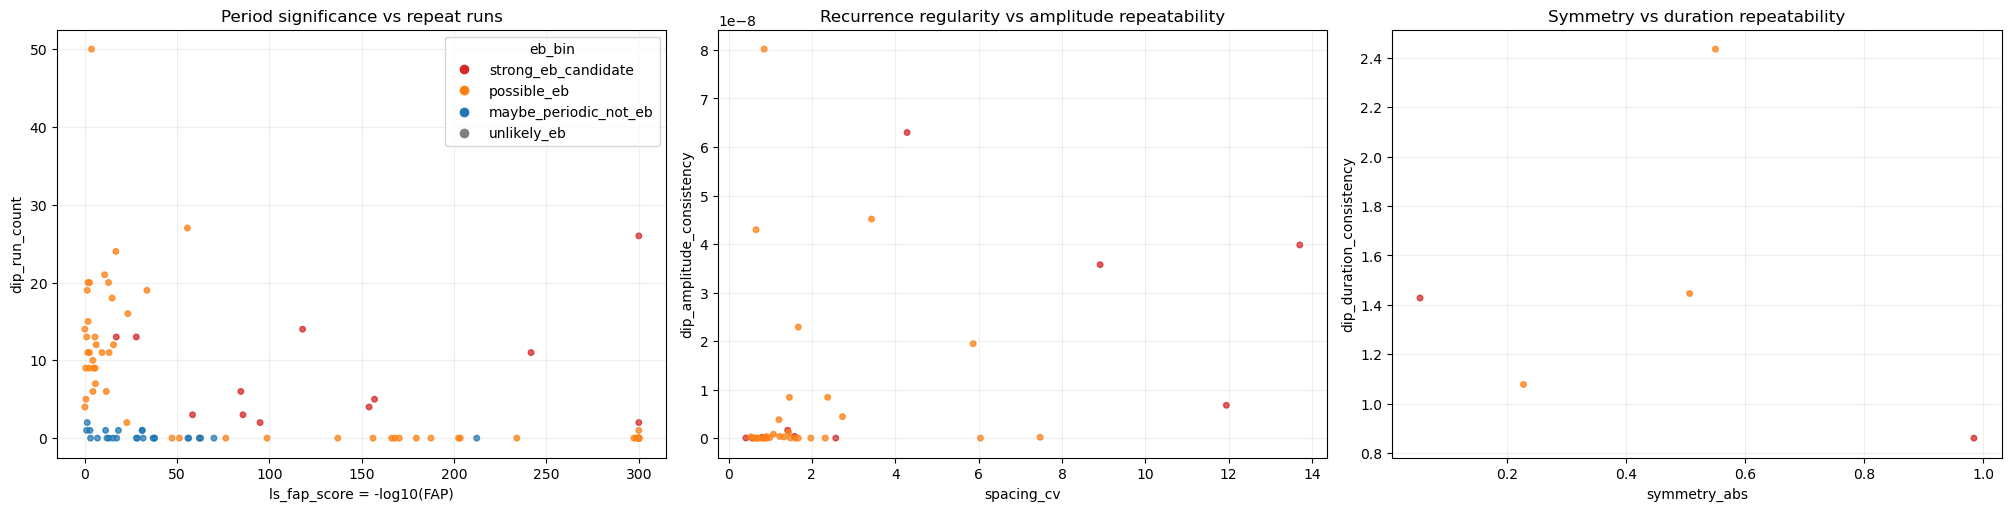

In [5]:
fig = build_eb_triage_summary_figure(triage_df)
plt.show()


In [6]:
top_cols = [
    col for col in [
        "candidate_id",
        "eb_likely_label",
        "eb_bin",
        "eb_score",
        "eb_score_notes",
        "stats_variability_lomb_scargle_best_period_days",
        "stats_variability_lomb_scargle_peak_power",
        "stats_variability_lomb_scargle_fap",
        "ls_fap_score",
        "dip_run_count",
        "dipper_n_valid_dips",
        "spacing_cv",
        "dip_amplitude_consistency",
        "dip_duration_consistency",
        "symmetry_abs",
        "stats_variability_von_neumann_ratio",
        "stats_variability_stetson_J",
        "dipper_score",
        "known_eb_hint",
        "known_periodic_hint",
        "gaia_var_class",
        "gaia_eb_period",
        "gaia_eb_morph",
        "vsx_class",
        "catalog_match",
        "local_lightcurve_exists",
    ] if col in triage_df.columns
]

likelihood_summary = (
    triage_df.groupby("eb_likely_label", dropna=False)
    .agg(
        n_candidates=("candidate_id", "size"),
        n_known_eb_hint=("known_eb_hint", "sum"),
        n_known_periodic_hint=("known_periodic_hint", "sum"),
        median_eb_score=("eb_score", "median"),
    )
    .sort_index()
)

display(Markdown("## Likely vs not-likely EB summary"))
display(likelihood_summary)

if {"eb_likely_label", "known_eb_hint"}.issubset(triage_df.columns):
    display(Markdown("Known EB hints are only a proxy sanity check, not ground truth."))
    display(pd.crosstab(triage_df["eb_likely_label"], triage_df["known_eb_hint"], margins=True))

likely_df = triage_df.loc[triage_df["eb_likely_flag"]].copy()
not_likely_df = triage_df.loc[~triage_df["eb_likely_flag"]].copy()

display(Markdown("## Candidates classified as likely EBs"))
display(likely_df[top_cols].head(100))

not_likely_sort_cols = [
    col for col in ["known_eb_hint", "known_periodic_hint", "eb_score", "dipper_score", "candidate_id"]
    if col in not_likely_df.columns
]
if not_likely_sort_cols:
    not_likely_df = not_likely_df.sort_values(
        not_likely_sort_cols,
        ascending=[col == "candidate_id" for col in not_likely_sort_cols],
        na_position="last",
    )

display(Markdown("## Candidates classified as not likely EBs"))
display(not_likely_df[top_cols].head(100))


## Likely vs not-likely EB summary

,n_candidates,n_known_eb_hint,n_known_periodic_hint,median_eb_score
eb_likely_label,,,,
likely_eb,71,11,49,5.0
not_likely_eb,25,0,12,2.0


Known EB hints are only a proxy sanity check, not ground truth.

known_eb_hint,False,True,All
eb_likely_label,,,
likely_eb,60,11,71
not_likely_eb,25,0,25
All,85,11,96


## Candidates classified as likely EBs

,candidate_id,eb_likely_label,eb_bin,eb_score,eb_score_notes,stats_variability_lomb_scargle_best_period_days,stats_variability_lomb_scargle_peak_power,stats_variability_lomb_scargle_fap,ls_fap_score,dip_run_count,...,stats_variability_stetson_J,dipper_score,known_eb_hint,known_periodic_hint,gaia_var_class,gaia_eb_period,gaia_eb_morph,vsx_class,catalog_match,local_lightcurve_exists
0,240519014553,likely_eb,strong_eb_candidate,9,"period:3, repeat_runs:3, amp_consistent:1, von...",303.497580,0.553646,1.227928e-157,156.910827,5.0,...,22.096137,20.723628,False,False,,NaN,,NaN,0,True
1,103080380860,likely_eb,strong_eb_candidate,9,"period:3, repeat_runs:2, amp_consistent:1, sym...",189.717370,0.500319,1.113448e-95,94.953330,2.0,...,12.671749,21.013788,False,False,,NaN,,NaN,0,True
2,240518624719,likely_eb,strong_eb_candidate,9,"period:3, repeat_runs:3, amp_consistent:1, von...",1150.435520,0.317063,2.874802e-85,84.541392,6.0,...,3.001607,24.355438,False,True,,NaN,,UXOR,1,True
3,549756460341,likely_eb,strong_eb_candidate,8,"period:3, repeat_runs:3, amp_consistent:1, ste...",0.557141,0.624489,0.000000e+00,300.000000,26.0,...,1.219975,21.662735,False,True,,NaN,,NaN,1,True
4,343598268424,likely_eb,strong_eb_candidate,8,"period:3, repeat_runs:2, amp_consistent:1, von...",323.621041,0.607163,0.000000e+00,300.000000,2.0,...,9.101758,20.705012,False,False,,NaN,,NaN,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,292058324105,likely_eb,possible_eb,5,"period:1, repeat_runs:3, amp_consistent:1",1.025967,0.020154,8.741837e-02,1.058397,13.0,...,0.153763,21.767232,False,False,,NaN,,VAR,0,True
67,103080558747,likely_eb,possible_eb,5,"period:1, repeat_runs:3, amp_consistent:1",29.588423,0.031180,2.250377e-01,0.647745,5.0,...,0.301244,23.298628,True,True,ECL,14.510952,TWOGAUSSIANS_WITH_ELLIPSOIDAL_ON_ECLIPSE2,NaN,1,True
68,377958123426,likely_eb,possible_eb,5,"period:1, repeat_runs:3, amp_consistent:1",2497.916364,0.016276,2.745844e-01,0.561324,9.0,...,0.058593,-1.642051,False,True,,NaN,,VAR,1,True
69,51540417731,likely_eb,possible_eb,5,"period:1, repeat_runs:3, amp_consistent:1",19.815808,0.028846,7.961510e-01,0.099005,4.0,...,0.372814,23.465838,True,True,ECL,10.519886,TWOGAUSSIANS_WITH_ELLIPSOIDAL_ON_ECLIPSE2,NaN,1,True


## Candidates classified as not likely EBs

,candidate_id,eb_likely_label,eb_bin,eb_score,eb_score_notes,stats_variability_lomb_scargle_best_period_days,stats_variability_lomb_scargle_peak_power,stats_variability_lomb_scargle_fap,ls_fap_score,dip_run_count,...,stats_variability_stetson_J,dipper_score,known_eb_hint,known_periodic_hint,gaia_var_class,gaia_eb_period,gaia_eb_morph,vsx_class,catalog_match,local_lightcurve_exists
72,51540459002,not_likely_eb,maybe_periodic_not_eb,4,"period:3, stetson:1",10.514931,0.333081,8.408662e-63,62.075273,0.0,...,4.148335,0.000000,False,True,RS,NaN,,NaN,1,True
71,575525955627,not_likely_eb,maybe_periodic_not_eb,4,"period:3, stetson:1",5652.081220,0.432651,5.351664e-213,212.271511,0.0,...,4.046307,0.000000,False,True,RS,NaN,,NaN,1,True
78,17181086812,not_likely_eb,maybe_periodic_not_eb,3,"period:1, von_neumann:1, stetson:1",418.592232,0.176987,3.100284e-29,28.508599,0.0,...,16.020719,0.000000,False,True,LPV,NaN,,NaN,1,True
74,635655321914,not_likely_eb,maybe_periodic_not_eb,3,"period:1, von_neumann:1, stetson:1",702.315795,0.122878,1.096853e-70,69.959851,0.0,...,2.400117,0.000000,False,True,BE|GCAS|SDOR|WR,NaN,,VAR,1,True
76,644245811932,not_likely_eb,maybe_periodic_not_eb,3,"period:1, von_neumann:1, stetson:1",194.904298,0.154376,2.310159e-38,37.636358,0.0,...,2.632847,0.000000,False,True,BE|GCAS|SDOR|WR,NaN,,WR,1,True
75,661424982307,not_likely_eb,maybe_periodic_not_eb,3,"period:1, von_neumann:1, stetson:1",28223.494800,0.198304,4.635510e-57,56.333902,0.0,...,12.991022,0.000000,False,True,,NaN,,NaN,1,True
83,292058452131,not_likely_eb,maybe_periodic_not_eb,2,"period:1, stetson:1",14.742196,0.136063,7.727678e-32,31.111951,1.0,...,2.976981,21.219367,False,True,RS,NaN,,NaN,1,True
94,94490404926,not_likely_eb,maybe_periodic_not_eb,2,"period:1, stetson:1",1.296984,0.014427,9.669291e-02,1.014605,1.0,...,1.634327,20.529875,False,True,,NaN,,NaN,1,True
93,146029670219,not_likely_eb,maybe_periodic_not_eb,2,"period:1, stetson:1",5.880511,0.039899,1.334462e-03,2.874694,1.0,...,7.149392,19.401162,False,True,,NaN,,NaN,1,True
89,25770251401,not_likely_eb,maybe_periodic_not_eb,2,"period:1, stetson:1",4288.257200,0.074221,9.069793e-13,12.042403,0.0,...,4.489681,0.000000,False,True,,NaN,,NaN,1,True


In [ ]:
display(Markdown("## Example individual light curves"))

example_lightcurve_plots = plot_example_lightcurves(
    triage_df,
    run_dir=PATH_ROOT,
    bins=EXAMPLE_BINS,
    examples_per_bin=EXAMPLES_PER_BIN,
    export_dir=Path(EXPORT_DIR) / "example_lightcurves",
    display_metadata=False,
    show=True,
)

if example_lightcurve_plots["selected"].empty:
    print("No local light curves were resolved for example plotting. Set RUN_DIR or BUNDLE_DIR and rerun this cell.")
else:
    example_cols = [
        col for col in [
            "candidate_id",
            "eb_bin",
            "eb_score",
            "stats_variability_lomb_scargle_best_period_days",
            "local_lightcurve_path",
        ] if col in example_lightcurve_plots["selected"].columns
    ]
    display(example_lightcurve_plots["selected"][example_cols])
    display(Markdown(
        f"Saved {len(example_lightcurve_plots['exported_paths'])} example plots to `{Path(EXPORT_DIR) / 'example_lightcurves'}`"
    ))


In [7]:
def inspect(candidate_id: str):
    """Show metadata and, when possible, raw + phase-folded plots for one candidate."""
    return inspect_candidate(triage_df, candidate_id, run_dir=PATH_ROOT)


print("Use inspect(<candidate_id>) to examine a candidate in detail.")
print("Example:")
print("    inspect(triage_df.iloc[0]['candidate_id'])")


Use inspect(<candidate_id>) to examine a candidate in detail.
Example:
    inspect(triage_df.iloc[0]['candidate_id'])
